# Aerial and latitude–height animations (Eriswil)

Notebook aligned with the publication pipeline: `scripts/processing_chain/run_publication_figures.py` reads
`config/publication_figures.yaml` (ensemble, paths, per-job CLI defaults). Process-budget and time-zero context live in
`config/psd_process_evolution.yaml`.

**Outputs:** frames under `output/gfx/png/aerials/<cs_run>/`, MP4/GIF under `output/gfx/mp4/` (same tree as other promoted figures; `run_publication_figures.py` syncs `output/gfx` → `output/gallery`).

**Data:** the notebook resolves `.../ensemble_output/<cs_run>` using the same fallbacks as `get_output_root` in `processing_paths.py`: `paths.server_root` in YAML, then `CS_RUNS_DIR`, `POLARCAP_OUTPUT_ROOT`, the Levante default tree, then local `scripts/data/registry/processed`. Jupyter kernels often lack shell exports—set `CS_RUNS_DIR` in IPython startup or assign `os.environ["CS_RUNS_DIR"] = "..."` before the config cell.



In [ ]:
import glob
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as md
import numpy as np
import pandas as pd
import xarray as xr
import yaml
from matplotlib.colors import LogNorm
from dask.diagnostics import ProgressBar
from utilities.ensemble_config_diff import print_ensemble_config_diff



def find_repo_root(start: Path | None = None) -> Path:
    """Match notebooks/spectral_waterfall_minimal: stable root from any cwd."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "utilities" / "spectral_waterfall.py").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook inside the polarcap_analysis repository.")

def _job_tokens(pub: dict, job_key: str) -> list[str]:
    out: list[str] = []
    for x in (pub.get("default_args") or {}).get(job_key, []) or []:
        out.extend(str(x).split())
    return out


def _flag_value(tokens: list[str], name: str) -> str | None:
    try:
        i = tokens.index(name)
    except ValueError:
        return None
    return tokens[i + 1] if i + 1 < len(tokens) else None


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
for path in (REPO_ROOT, SRC_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from utilities.model_helpers import fetch_3d_data, convert_units_3d, harmonize_experiment_time_to_finest
from utilities.namelist_metadata import update_dataset_metadata
from utilities.plotting import new_fjet2, set_name_tick_params, add_ruler
from utilities.processing_paths import find_ensemble_output_for_cs_run
from utilities.style_profiles import apply_publication_style
import utilities.tools as tools

from dask.diagnostics import ProgressBar
ProgressBar.register()

In [2]:
# Fetch publication + PSD configs (same files as the publication runner / cloud overview script)
xr.set_options(keep_attrs=True)
apply_publication_style()

PUBLICATION_YAML = REPO_ROOT / "config" / "publication_figures100m.yaml"
PSD_YAML = REPO_ROOT / "config" / "psd_process_evolution100m.yaml"
FLARE_IDX_LIST = [0, 1, 2, 3, 4]
REF_IDX_LIST = [0, 1, 1, 1, 1]

TIME_DEBUG_STRIDE = 4  # > 1 for development speed

# Load publication + PSD configs (same files as the publication runner / cloud overview script)
with open(PUBLICATION_YAML) as f:
    pub = yaml.safe_load(f) or {}
with open(PSD_YAML) as f:
    psd = yaml.safe_load(f) or {}

ens = pub.get("ensemble") or {}
cs_run = str(ens.get("cs_run", "cs-eriswil__20260318_153631"))
domain_xy = str(ens.get("domain", "200x160"))
flare_idx = int((psd.get("selection") or {}).get("experiment_index_default", 1))

server_root = os.environ.get("CS_RUNS_DIR")
ens_out, _tried = find_ensemble_output_for_cs_run(cs_run, config_runs_root=server_root)
if not ens_out:
    raise FileNotFoundError(
        "Could not find ensemble_output/"
        + cs_run
        + ". Tried:\n  "
        + "\n  ".join(_tried)
        + "\nSet paths.server_root in publication_figures.yaml, or export CS_RUNS_DIR "
        "(parent of RUN_ERISWILL_*x100), or POLARCAP_OUTPUT_ROOT (runs root or ensemble_output). "
        "Jupyter often does not inherit shell env: set variables in ~/.ipython/profile_default/startup "
        "or in this cell via os.environ before re-run."
    )
model_data_path = Path(ens_out) / cs_run

cf_tok = _job_tokens(pub, "cloud_field_overview")
runs_root = Path(server_root).expanduser() if server_root else Path(ens_out).parent
extpar_high = runs_root / "extPar_Eriswil_200x160.nc"
extpar_low = runs_root / "extPar_Eriswil_50x40.nc"
plot_start_s = _flag_value(cf_tok, "--plot-start")
plot_end_s = _flag_value(cf_tok, "--plot-end")
if domain_xy == "200x160":
    extpar_file = extpar_high
else:
    extpar_file = extpar_low

seed_start = np.datetime64((psd.get("time") or {}).get("seed_start", "2023-01-25T12:29:50"))

GFX_PNG = REPO_ROOT / "output" / "gfx" / "png" / "aerials" / cs_run.replace("/", "_")
GFX_MP4 = REPO_ROOT / "output" / "gfx" / "mp4"
GFX_PNG.mkdir(parents=True, exist_ok=True)
GFX_MP4.mkdir(parents=True, exist_ok=True)

print("cs_run:", cs_run, "domain:", domain_xy)
print("flare_idx:", flare_idx)
print("experiment:", model_data_path.name)

print("model_data_path:", model_data_path)
print("extpar_file:", extpar_file)
print("plot window (cloud_field_overview preset):", plot_start_s, "..", plot_end_s)


cs_run: cs-eriswil__20260318_153631 domain: 200x160
flare_idx: 3
experiment: cs-eriswil__20260318_153631
model_data_path: /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_200x160x100/ensemble_output/cs-eriswil__20260318_153631
extpar_file: /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/extPar_Eriswil_200x160.nc
plot window (cloud_field_overview preset): 2023-01-25T12:29:50 .. 2023-01-25T13:05:00


## Load 3D flare member and reference members

In [3]:
flist_3d = sorted(glob.glob(str(model_data_path / "3D_??????????????.nc")))
if not flist_3d:
    raise FileNotFoundError(f"No 3D_*.nc under {model_data_path}")

json_files = sorted(model_data_path.glob("*.json"))
if not json_files:
    raise FileNotFoundError(f"No ensemble json next to 3D files in {model_data_path}")
with open(json_files[0]) as jsonfile:
    meta = json.load(jsonfile)

exp_names = [Path(f).name.split("_")[-1].split(".")[0] for f in flist_3d]
flare_candidates = [exp for exp in exp_names if meta[exp]["INPUT_ORG"]["sbm_par"]["lflare"]]
ref_candidates = [exp for exp in exp_names if not meta[exp]["INPUT_ORG"]["sbm_par"]["lflare"]]
if not flare_candidates:
    raise ValueError("No flare experiments (lflare) in ensemble meta.")
if not ref_candidates:
    raise ValueError("No reference experiments (lflare=False) in ensemble meta.")

# Load flare + reference runs once; keep expname as coordinate.
load_candidates = flare_candidates + [e for e in ref_candidates if e not in flare_candidates]
_ds_blocks = []
_dtimes = []
for exp_name in load_candidates:
    nc_file = next(f for f in flist_3d if exp_name in f)
    ds_i = fetch_3d_data(
        str(nc_file),
        str(extpar_file),
        meta[exp_name]["INPUT_ORG"],
        var_sets=["meteo", "bulk", "spec"],
        chunks={"time": 1},
    )
    ds_i = update_dataset_metadata(ds_i)
    ds_i = ds_i.isel(altitude=slice(80, None))
    ds_i = convert_units_3d(ds_i, ds_i["rho"])
    _dtimes.append(ds_i.time.values[1] - ds_i.time.values[0])
    _ds_blocks.append(ds_i)

_times = _ds_blocks[np.argmax(_dtimes)].time

print(
    "OUTPUT cadence (sbm_par.nc_output_hcomb last entry = dt, seconds):",
    {e: meta[e]["INPUT_ORG"]["sbm_par"].get("nc_output_hcomb") for e in load_candidates},
)
# Keep native cadence in ds_3d to avoid expensive interpolation on full 3D fields.
# We harmonize to 10 s later on reduced animation fields only.
ds_3d = xr.concat(_ds_blocks, dim=pd.Index(load_candidates, name="expname"))

# Development/debug speed-up: use every 4th model time step.
if TIME_DEBUG_STRIDE > 1:
    ds_3d = ds_3d.reindex(time=_times)
    # ds_3d = ds_3d.isel(time=slice(None, None, TIME_DEBUG_STRIDE))

flare_exp_name = flare_candidates[flare_idx]
print("flare_candidates:", flare_candidates)
print("ref_candidates:", ref_candidates)
print("loaded expname:", list(ds_3d.expname.values))
print("time_debug_stride:", TIME_DEBUG_STRIDE, "n_time:", ds_3d.sizes.get("time"))
print("default flare_exp_name (paths, tracking):", flare_exp_name)
print_ensemble_config_diff(meta, load_candidates)

OUTPUT cadence (sbm_par.nc_output_hcomb last entry = dt, seconds): {'20260318153634': [1730, 4000, 30], '20260318153638': [1730, 4000, 30], '20260324165035': [1730, 4000, 10], '20260324165038': [1730, 4000, 10], '20260324165040': [1730, 4000, 10], '20260318153631': [1730, 4000, 30], '20260318153636': [1730, 4000, 30]}


/tmp/ipykernel_2377658/1820714711.py:46: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_3d = xr.concat(_ds_blocks, dim=pd.Index(load_candidates, name="expname"))


flare_candidates: ['20260318153634', '20260318153638', '20260324165035', '20260324165038', '20260324165040']
ref_candidates: ['20260318153631', '20260318153636']
loaded expname: ['20260318153634', '20260318153638', '20260324165035', '20260324165038', '20260324165040', '20260318153631', '20260318153636']
time_debug_stride: 4 n_time: 77
default flare_exp_name (paths, tracking): 20260324165038
Ensemble config differences (COSMO-SPECS / INPUT_ORG)
experiments (7): 20260318153634, 20260318153638, 20260324165035, 20260324165038, 20260324165040, 20260318153631, 20260318153636

INPUT_ORG.flare_sbm.flare_dn
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 400.0
  20260324165038: 400.0
  20260324165040: 400.0
  20260318153631: 0.0
  20260318153636: 0.0

INPUT_ORG.flare_sbm.flare_dp
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 1e-07
  20260324165038: 1e-07
  20260324165040: 1e-07
  20260318153631: 0.0
  20260318153636: 0.0

INPUT_ORG.flare_sbm.flare_emission
  202603

In [4]:
# Map-view layout: figure size from publication DPI (matches savefig in analysis scripts)
_dpi = float(plt.rcParams["savefig.dpi"])
pixel_w, pixel_h = 1920, 1080
resolution_label = "400m" if domain_xy == "50x40" else "100m"
resolution_deg = 0.004 if domain_xy == "50x40" else 0.001

cfg = {
    "resolution": resolution_label,
    "resolution_deg": resolution_deg,
    "dpi": int(_dpi),
    "pixel_size_latlon": (pixel_w, pixel_h),
    "pixel_size_latheight": (pixel_w, pixel_h//1.75),
    "poolsize": min(8, os.cpu_count() or 4),
    "plot_all_frames": True,
    # Lat–height panel: faint HSURF columns + thick mean, or one column synced to frame index. ("individual", "all_mean")
    "latheight_surf_mode": "all_mean", 
    "flare_lat": 47.07425,
    "flare_lon": 7.90522,
    "origin_lat": 47.070522,
    "origin_lon": 7.872991,
    "plot_xlim": (7.7671843, 7.94),
    "plot_ylim": (47.02, 47.12),
    "delta_x": float(1e3 * np.mean(np.diff(ds_3d.longitude.values)) * 111.13295254925466),
    "delta_y": float(1e3 * np.mean(np.diff(ds_3d.latitude.values)) * 111.13295254925466),
    "delta_t": float(np.mean(np.diff(ds_3d.time.astype("datetime64[s]")).astype(float))),
    "n_lon": ds_3d.longitude.size,
    "n_lat": ds_3d.latitude.size,
    "n_time": ds_3d.time.size,
    "vel_lims": [-0.5, 0.5],
    "v_lims_qi": [1e1, 1e4],
    "tick_size": int(plt.rcParams["xtick.labelsize"] + 1),
    "axis_size": int(plt.rcParams["axes.labelsize"] + 2),
    "timer_size": int(plt.rcParams["figure.titlesize"] + 6),
}

data_extpar = xr.open_mfdataset(str(extpar_file), chunks="auto")
# for top view
lat2d = data_extpar["lat"].values[7:-7, 7:-7]
lon2d = data_extpar["lon"].values[7:-7, 7:-7]
height = data_extpar["HSURF"].values[7:-7, 7:-7]

# for lat-height view
lat1d = data_extpar["lat"].mean("rlon").values[7:-7]
surf_height = data_extpar["HSURF"].values[7:-7, 7:-7]
surf_height_mean = data_extpar["HSURF"].mean("rlon").values[7:-7]



In [5]:
# Flare–reference pairs from FLARE_IDX_LIST / REF_IDX_LIST (indices into flare_candidates / ref_candidates).
eps_f32 = np.finfo(np.float32).eps

def _ishape_of(exp_name): return meta[exp_name]["INPUT_ORG"]["sbm_par"].get("ishape")
def _flare_emission_inp_of(exp_name): return meta[exp_name]["INPUT_ORG"]["flare_sbm"].get("flare_emission")
def _flare_emission_ccn_of(exp_name): return meta[exp_name]["INPUT_ORG"]["flare_sbm"].get("flare_dn")

_fi = list(FLARE_IDX_LIST)
_ri = list(REF_IDX_LIST)
if len(_fi) != len(_ri): raise ValueError(f"FLARE_IDX_LIST length {len(_fi)} != REF_IDX_LIST length {len(_ri)}")

pair_rows = []
for j, (i_f, i_r) in enumerate(zip(_fi, _ri)):
    if not (0 <= i_f < len(flare_candidates)): raise IndexError(f"FLARE_IDX_LIST[{j}]={i_f} invalid for len(flare_candidates)={len(flare_candidates)}")
    if not (0 <= i_r < len(ref_candidates)):   raise IndexError(f"REF_IDX_LIST[{j}]={i_r} invalid for len(ref_candidates)={len(ref_candidates)}")
    fexp, rexp = flare_candidates[i_f], ref_candidates[i_r]
    pair_rows.append((  fexp, 
                        rexp, 
                        _ishape_of(fexp),
                         _flare_emission_inp_of(fexp), 
                        _flare_emission_ccn_of(fexp)) )

n_pair = len(pair_rows)
if n_pair < 1: raise ValueError("No pairs built from FLARE_IDX_LIST / REF_IDX_LIST.")

for i in range(n_pair):
    print(f"pair {i} (flare_i, ref_i):", list(zip(_fi, _ri))[i])
    print(f"pair {i} (flare, ref, ishape, flare_emission_inp, flare_emission_ccn):", pair_rows[i])

_col = ds_3d[["nw", "nf", "dz"]].sel(
    latitude=slice(None, cfg["flare_lat"] + 2.0 * cfg["resolution_deg"]),
    longitude=slice(None, cfg["flare_lon"] + 2.0 * cfg["resolution_deg"]),
)
_col = _col.isel(diameter=slice(30, None)).sum("diameter")
_col = (_col[["nw", "nf"]] * _col["dz"]).sum("altitude")
_col = xr.where(_col < eps_f32, np.nan, _col)

itime_cmp = int(_col.sizes["time"] // 2) # select middle time step for comparison
_tlab = str(np.asarray(_col.time.isel(time=itime_cmp).values).squeeze())
_d0 = _col["nf"].isel(time=itime_cmp).sel(expname=pair_rows[0][0])

if "longitude2D" in _d0.coords:
    lon_q = _d0.longitude2D.values
    lat_q = _d0.latitude2D.values
else:
    lon_q, lat_q = np.meshgrid(_d0.longitude.values, _d0.latitude.values)


pair 0 (flare_i, ref_i): (0, 0)
pair 0 (flare, ref, ishape, flare_emission_inp, flare_emission_ccn): ('20260318153634', '20260318153631', 2, 1000000.0, 0.0)
pair 1 (flare_i, ref_i): (1, 1)
pair 1 (flare, ref, ishape, flare_emission_inp, flare_emission_ccn): ('20260318153638', '20260318153636', 4, 1000000.0, 0.0)
pair 2 (flare_i, ref_i): (2, 1)
pair 2 (flare, ref, ishape, flare_emission_inp, flare_emission_ccn): ('20260324165035', '20260318153636', 4, 1000000.0, 400.0)
pair 3 (flare_i, ref_i): (3, 1)
pair 3 (flare, ref, ishape, flare_emission_inp, flare_emission_ccn): ('20260324165038', '20260318153636', 4, 3000000.0, 400.0)
pair 4 (flare_i, ref_i): (4, 1)
pair 4 (flare, ref, ishape, flare_emission_inp, flare_emission_ccn): ('20260324165040', '20260318153636', 4, 10000000.0, 400.0)


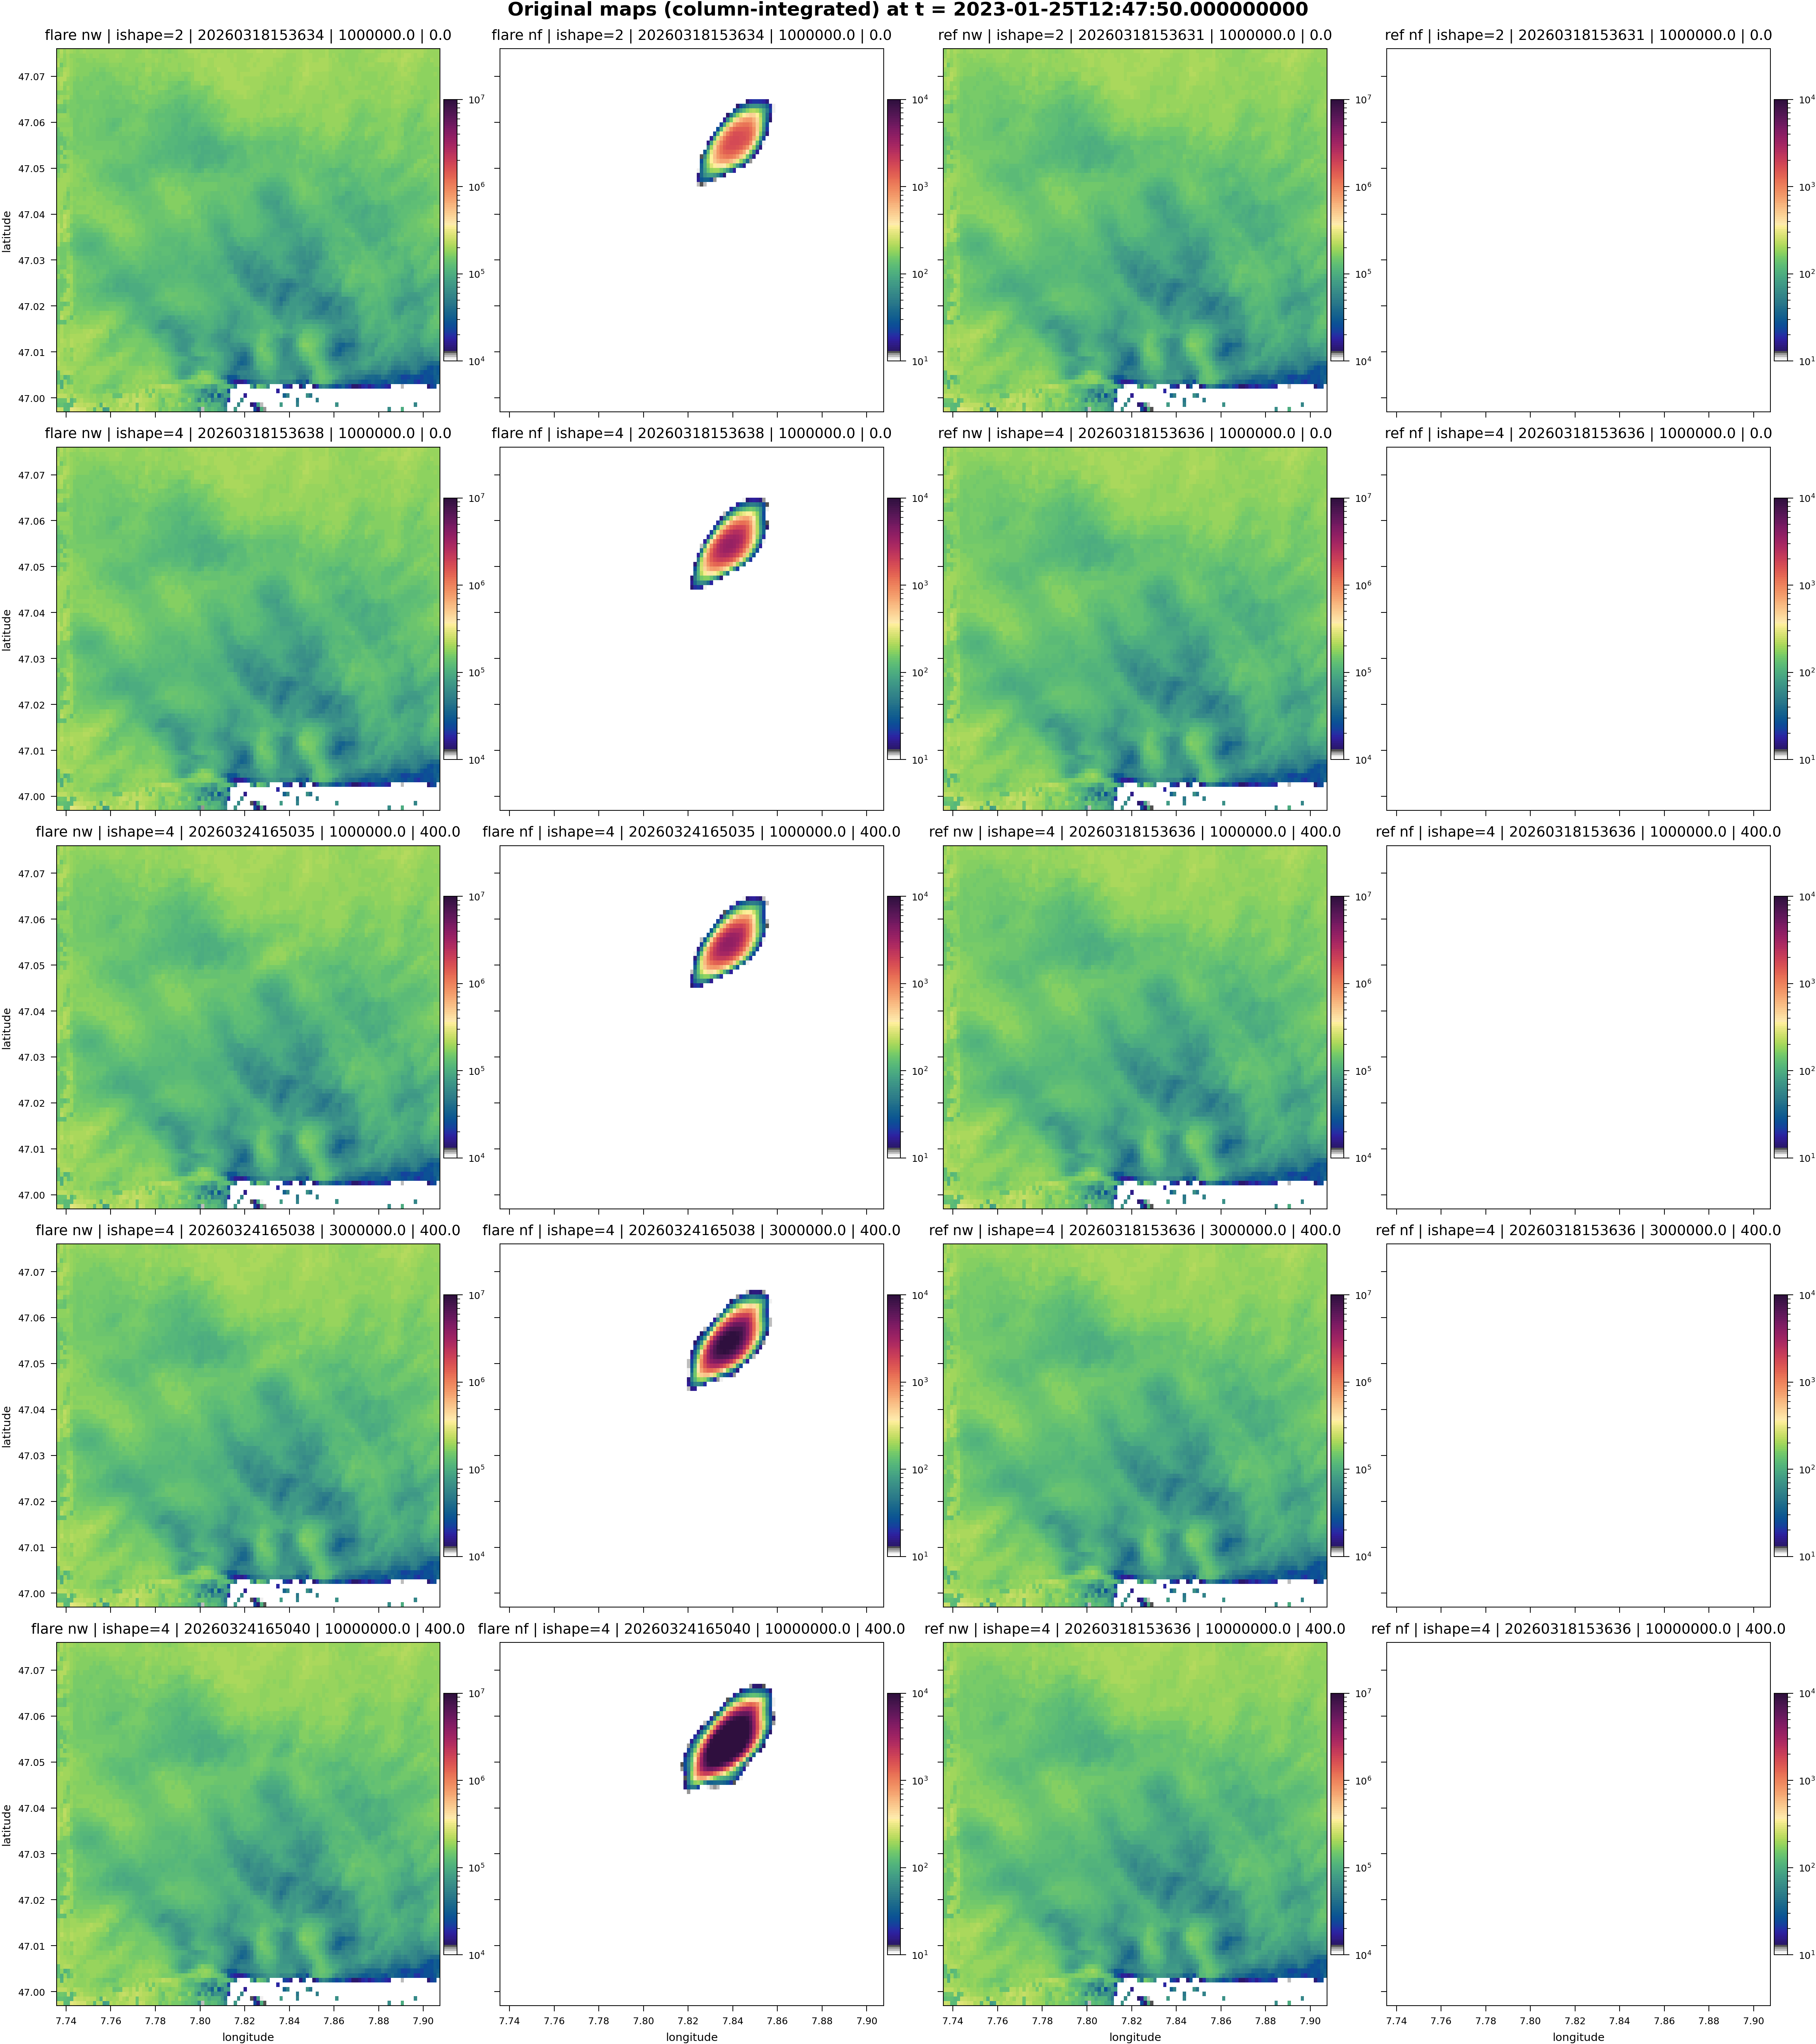

In [6]:
# 1) Originals: n_flare_runs x 4 -> [flare_nw, flare_nf, ref_nw, ref_nf]
fig_org, axs_org = plt.subplots(n_pair, 4, figsize=(16.0, 3.6 * n_pair), sharex=True, sharey=True, constrained_layout=True)
if n_pair == 1:
    axs_org = np.array([axs_org])
        
orig_vmin = {"nw": 1e4, "nf": 1e1}
orig_vmax = {"nw": 1e7, "nf": 1e4}

for i, (fexp, rexp, ish, _, _) in enumerate(pair_rows):
    panel_data = [
        ("flare nw", _col["nw"].isel(time=itime_cmp).sel(expname=fexp), orig_vmin["nw"], orig_vmax["nw"]),
        ("flare nf", _col["nf"].isel(time=itime_cmp).sel(expname=fexp), orig_vmin["nf"], orig_vmax["nf"]),
        ("ref nw",   _col["nw"].isel(time=itime_cmp).sel(expname=rexp), orig_vmin["nw"], orig_vmax["nw"]),
        ("ref nf",   _col["nf"].isel(time=itime_cmp).sel(expname=rexp), orig_vmin["nf"], orig_vmax["nf"]),
    ]
    for j, (lbl, da_, vmin_, vmax_) in enumerate(panel_data):
        pm = axs_org[i, j].pcolormesh( lon_q, lat_q, da_.values, shading="nearest", cmap=new_fjet2, norm=LogNorm(vmin=vmin_, vmax=vmax_) )
        axs_org[i, j].set_title(f"{lbl} | ishape={ish} | {fexp if 'flare' in lbl else rexp} | {_flare_emission_inp_of(fexp)} | {_flare_emission_ccn_of(fexp)}", fontsize=9)
        fig_org.colorbar(pm, ax=axs_org[i, j], shrink=0.72, pad=0.01)
    
    axs_org[i, 0].set_ylabel("latitude")

for j in range(4):
    axs_org[-1, j].set_xlabel("longitude")
fig_org.suptitle(f"Original maps (column-integrated) at t = {_tlab}", fontsize=12)
fig_org.savefig(GFX_PNG / f"original_maps_{cfg['resolution']}_{cs_run.replace('__', '_')}.png")


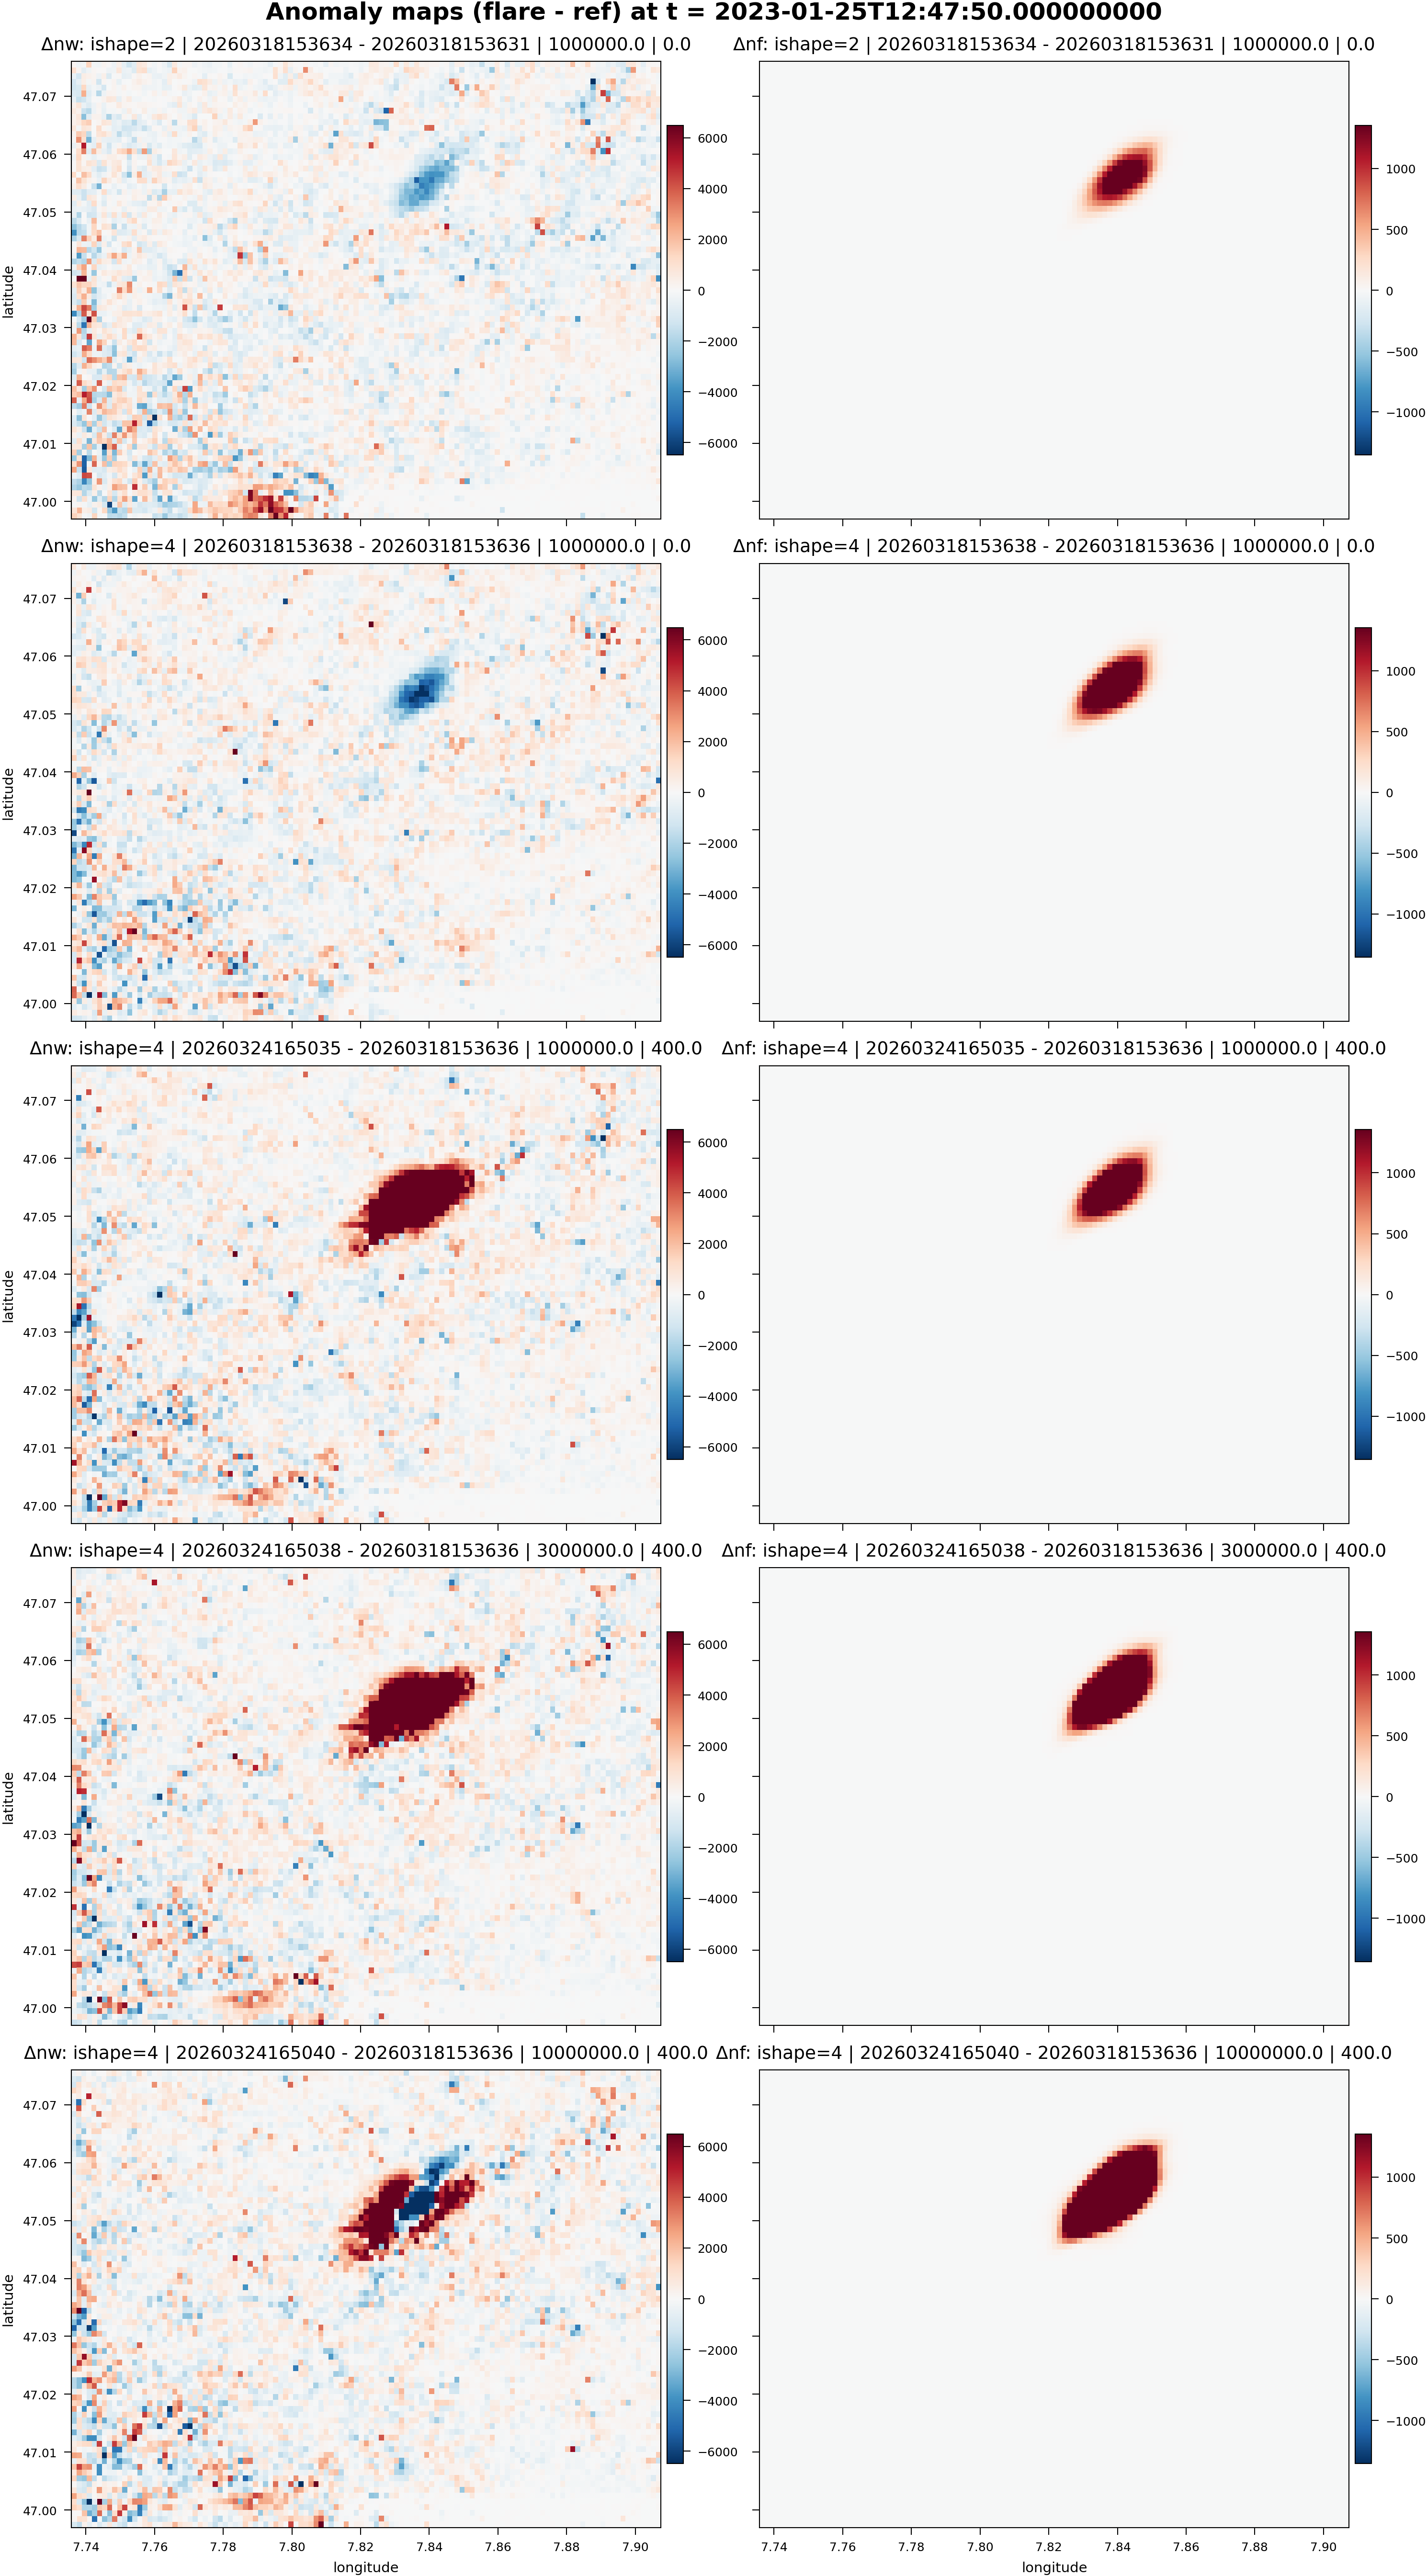

In [ ]:
# 2) Anomaly: n_flare_runs x 2 -> [nw_anom, nf_anom] where anomaly = flare - ref.
anom_list = []
for fexp, rexp, ish, _, _ in pair_rows:
    anom_list.append((
        fexp, rexp, ish, {  "nw": _col["nw"].isel(time=itime_cmp).sel(expname=fexp) - _col["nw"].isel(time=itime_cmp).sel(expname=rexp),
                            "nf": _col["nf"].isel(time=itime_cmp).sel(expname=fexp) - _col["nf"].isel(time=itime_cmp).sel(expname=rexp)  },
    ))

fig_anom, axs_anom = plt.subplots(n_pair, 2, figsize=(10.0, 3.6 * n_pair), sharex=True, sharey=True, constrained_layout=True)
if n_pair == 1:
    axs_anom = np.array([axs_anom])
anom_vmax = {}
for v in ["nw", "nf"]:
    vals = np.array([a[3][v].values for a in anom_list])
    anom_vmax[v] = max(float(np.nanpercentile(np.abs(vals), 99.0)), 1e-12)

for i, (fexp, rexp, ish, anom) in enumerate(anom_list):
    for j, v in enumerate(["nw", "nf"]):
        vm = anom_vmax[v]
        pm = axs_anom[i, j].pcolormesh( lon_q, lat_q, anom[v].values, shading="nearest", cmap="RdBu_r", vmin=-vm, vmax=vm )
        axs_anom[i, j].set_title(f"Δ{v}: ishape={ish} | {fexp} - {rexp} | {_flare_emission_inp_of(fexp):.0e} | {_flare_emission_ccn_of(fexp)}", fontsize=9)
        fig_anom.colorbar(pm, ax=axs_anom[i, j], shrink=0.72, pad=0.01)
    
    axs_anom[i, 0].set_ylabel("latitude")
    
for j in range(2):
    axs_anom[-1, j].set_xlabel("longitude")
    
fig_anom.suptitle(f"Anomaly maps (flare - ref) at t = {_tlab}", fontsize=12)
fig_anom.savefig(GFX_PNG / f"anomaly_maps_{cfg['resolution']}_{cs_run.replace('__', '_')}.png")



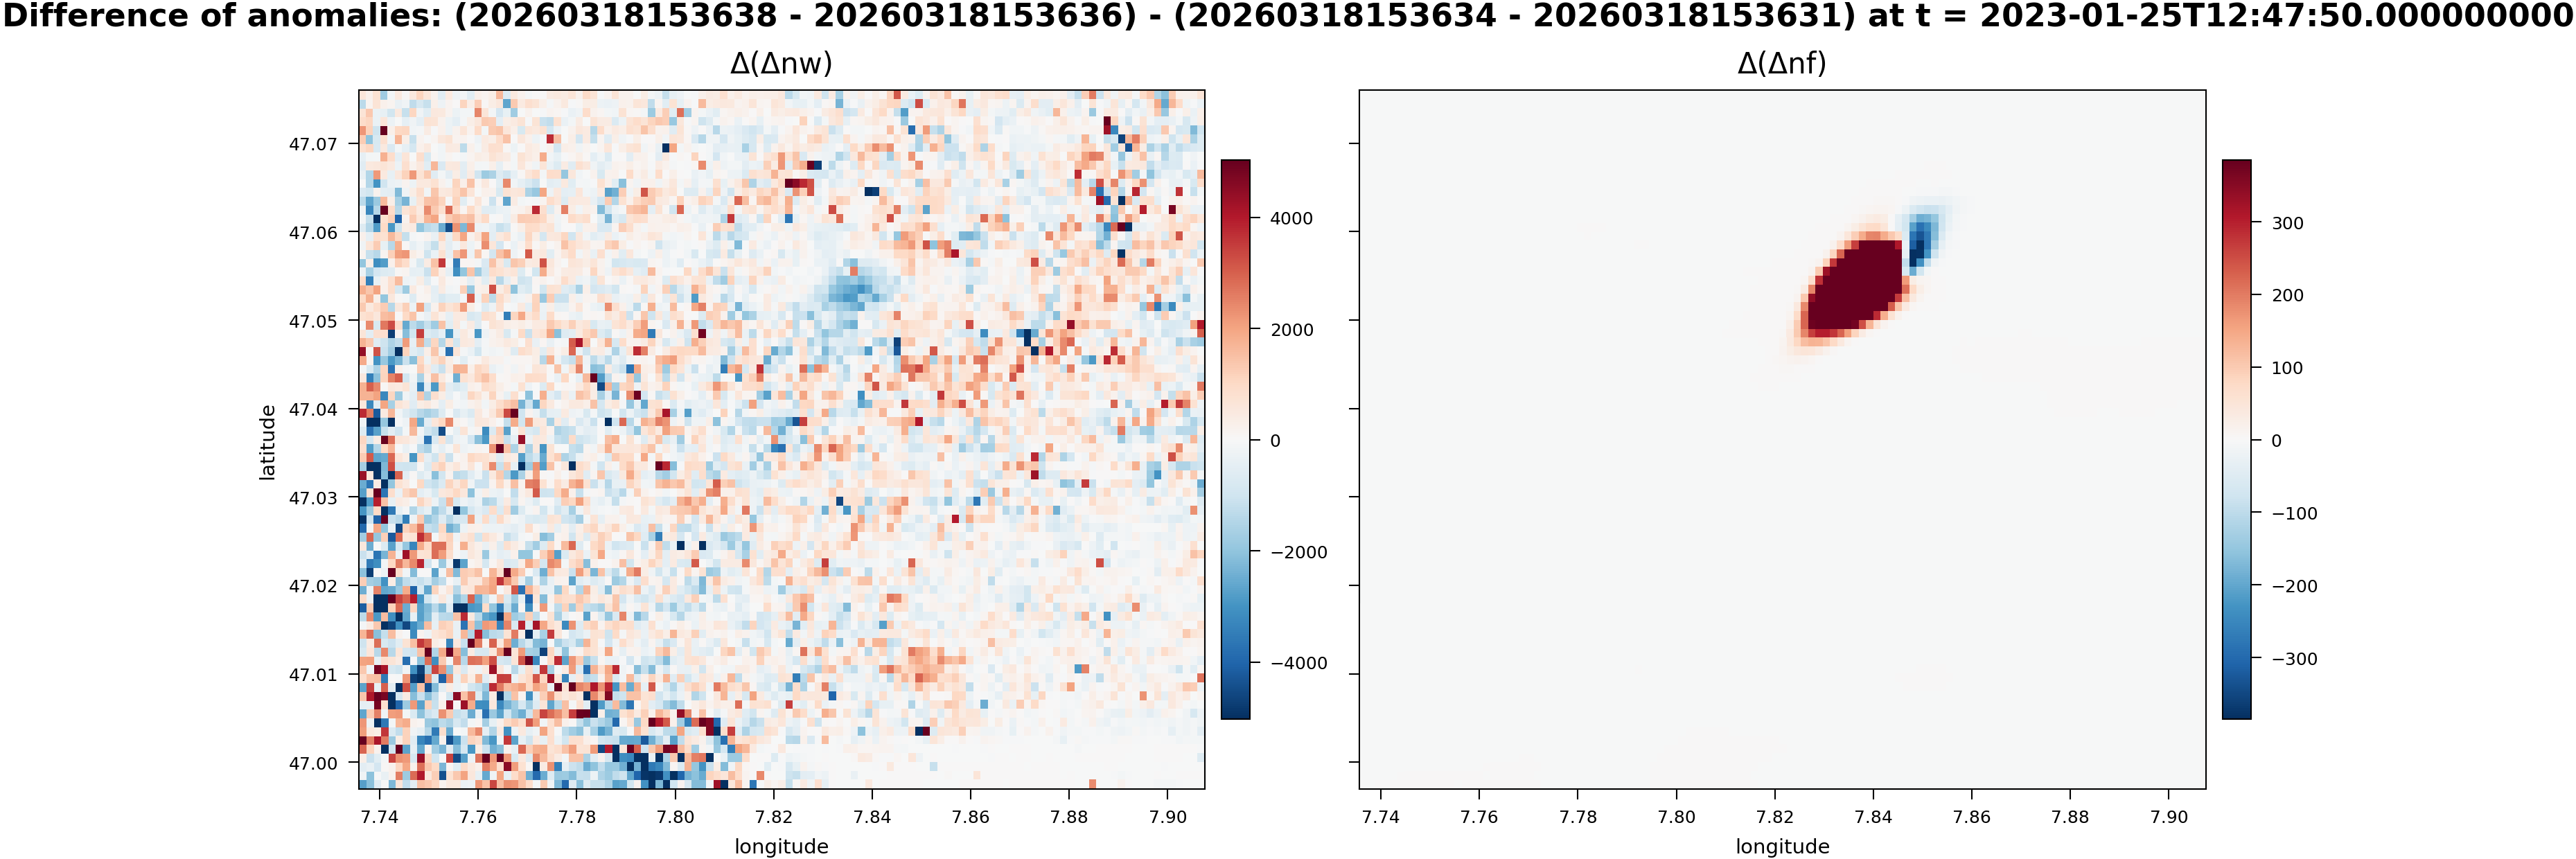

In [8]:
# 3) Difference of anomalies (nw, nf): using first two anomaly pairs.
if n_pair >= 2:
    diff_anom = { "nw": anom_list[1][3]["nw"] - anom_list[0][3]["nw"],
                  "nf": anom_list[1][3]["nf"] - anom_list[0][3]["nf"] }
    fig_da, axs_da = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True, constrained_layout=True)
    for j, v in enumerate(["nw", "nf"]):
        vm = max(float(np.nanpercentile(np.abs(diff_anom[v].values), 99.0)), 1e-12)
        pm = axs_da[j].pcolormesh( lon_q, lat_q, diff_anom[v].values, shading="nearest", cmap="RdBu_r", vmin=-vm, vmax=vm)
        axs_da[j].set_title(f"Δ(Δ{v})", fontsize=10)
        axs_da[j].set_xlabel("longitude")
        fig_da.colorbar(pm, ax=axs_da[j], shrink=0.80, pad=0.02)
        
    axs_da[0].set_ylabel("latitude")
    p0 = f"({anom_list[0][0]} - {anom_list[0][1]})"
    p1 = f"({anom_list[1][0]} - {anom_list[1][1]})"
    fig_da.suptitle(f"Difference of anomalies: {p1} - {p0} at t = {_tlab}", fontsize=11)
    fig_da.savefig(GFX_PNG / f"difference_of_anomalies_{cfg['resolution']}_{cs_run.replace('__', '_')}.png")
else:
    print("Need >=2 pairs for difference-of-anomalies figure.")

## Plotting helpers (top view)

In [ ]:
def add_map_annotations(ax, cfg):
    ax.scatter(cfg["origin_lon"], cfg["origin_lat"], s=70, marker="x", color="red", zorder=2)
    ax.scatter(cfg["flare_lon"],  cfg["flare_lat"],  s=50, marker="o", facecolor="none", edgecolor="white", lw=2.5,zorder=2)
    ax.scatter(cfg["flare_lon"],  cfg["flare_lat"],  s=50, marker="o", facecolor="none", edgecolor="red", lw=1.0, zorder=2 )
    add_ruler(ax, 47.05, 7.804, cfg["flare_lat"], cfg["flare_lon"])
    seeding = {
        "royalblue": ([7.90476, 7.90568], [47.07602, 47.07248]),
        "orange": ([7.89828, 7.89919], [47.07526, 47.07172]),
        "green": ([7.91125, 7.91216], [47.07676, 47.07322]),
    }
    for _c, (lon, lat) in seeding.items():
        dx, dy = np.diff(lon)[0], np.diff(lat)[0]
        ext_lon, ext_lat = [lon[0] - dx, lon[1] + dx], [lat[0] - dy, lat[1] + dy]
        ax.plot(lon, lat, color="black", lw=0.9)
        ax.plot(ext_lon, ext_lat, color="black", alpha=0.4, lw=0.6)


## Top-view animation

In [ ]:
apply_publication_style()
png_path = str(GFX_PNG)
os.makedirs(png_path, exist_ok=True)

# Build plan-view ICNC fields for all flare runs (columns).
plan_nf_by_exp = {}
plan_nw_by_exp = {}
for exp in flare_candidates:
    mod_e = ds_3d.sel(expname=exp)[["nf", "nw", "dz"]].sel(
        latitude=slice(None, cfg["flare_lat"] + 2.0 * cfg["resolution_deg"]),
        longitude=slice(None, cfg["flare_lon"] + 2.0 * cfg["resolution_deg"]),
    )
    mod_e = mod_e.isel(diameter=slice(30, None)).sum("diameter")
    mod_e = (mod_e[["nf", "nw"]] * mod_e["dz"]).sum("altitude")
    mod_e = xr.where(mod_e < np.finfo(np.float32).eps, np.nan, mod_e).persist()
    plan_nf_by_exp[exp] = mod_e["nf"]
    plan_nw_by_exp[exp] = mod_e["nw"]

# Harmonize Top-view time to the finest cadence (10 s) on reduced 2D fields only.
plan_nf_blocks = [plan_nf_by_exp[exp].to_dataset(name="nf") for exp in flare_candidates]
plan_nw_blocks = [plan_nw_by_exp[exp].to_dataset(name="nw") for exp in flare_candidates]
plan_nf_blocks = harmonize_experiment_time_to_finest(plan_nf_blocks, exp_names=flare_candidates)
plan_nw_blocks = harmonize_experiment_time_to_finest(plan_nw_blocks, exp_names=flare_candidates)
for exp, ds_h in zip(flare_candidates, plan_nf_blocks):
    plan_nf_by_exp[exp] = ds_h["nf"]
for exp, ds_h in zip(flare_candidates, plan_nw_blocks):
    plan_nw_by_exp[exp] = ds_h["nw"]


In [ ]:
n_flare = len(flare_candidates)
time_vals = plan_nf_by_exp[flare_candidates[0]].time.values

fig_w = (cfg["pixel_size_latheight"][0] / cfg["dpi"])
fig_h = cfg["pixel_size_latheight"][1] / cfg["dpi"] * max(1, n_flare)
fig_ll, axes = plt.subplots(n_flare, 2, figsize=(fig_w, fig_h), sharex=True, sharey=True, constrained_layout=True)
if n_flare == 1:
    axs = np.array([axes])

pm_nf_all, pm_nw_all = [], []
for axs, exp in zip(axes, flare_candidates):
    for ax in axs:
        set_name_tick_params(ax)
        ax.tick_params(axis="both", which="major", labelsize=cfg["tick_size"])
        add_map_annotations(ax, cfg)
        ax.pcolormesh(lon2d, lat2d, height, cmap="terrain", vmin=300, alpha=0.55, zorder=1)
        
    pm_nf = axs[0].pcolormesh(
        plan_nf_by_exp[exp].longitude2D,
        plan_nf_by_exp[exp].latitude2D,
        np.asarray(plan_nf_by_exp[exp].isel(time=0).values),
        cmap=new_fjet2,
        norm=LogNorm(*cfg["v_lims_qi"]),
        zorder=50,
    )
    pm_nf_all.append(pm_nf)
    pm_nw = axs[1].pcolormesh(
        plan_nw_by_exp[exp].longitude2D,
        plan_nw_by_exp[exp].latitude2D,
        np.asarray(plan_nw_by_exp[exp].isel(time=0).values),
        cmap=new_fjet2,
        norm=LogNorm(*cfg["v_lims_qi"]),
        zorder=50,
    )
    pm_nw_all.append(pm_nw)
    for ax, lbl in zip(axs, ["nf", "nw"]):
        ax.set_title(f"{lbl} | {exp}", fontsize=cfg["axis_size"], weight="semibold")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)

fig_ll.text(0.5, 0.03, "longitude / (°)", ha="center", va="center", fontsize=cfg["axis_size"])
fig_ll.text(0.01, 0.5, "latitude / (°)", ha="center", va="center", fontsize=cfg["axis_size"], rotation="vertical")
cb_nf = fig_ll.colorbar(pm_nf_all[0], ax=axes[0,0], extend="both", shrink=0.85, aspect=25, pad=0.02, orientation="horizontal", location="top")
cb_nf.set_label(r"$\sum$ ICNC (m$^{-2}$)", fontsize=cfg["axis_size"] - 1)
cb_nf.ax.tick_params(labelsize=cfg["tick_size"])
cb_nw = fig_ll.colorbar(pm_nw_all[0], ax=axes[0,1], extend="both", shrink=0.85, aspect=25, pad=0.02, orientation="horizontal", location="top")
cb_nw.set_label(r"$\sum$ ICNC (m$^{-2}$)", fontsize=cfg["axis_size"] - 1)
cb_nw.ax.tick_params(labelsize=cfg["tick_size"])

fig_ll.suptitle("Top-view flare ICNC evolution", fontsize=cfg["timer_size"] - 1, weight="semibold", y=0.995)

for pattern in ("lat_lon_frame_*.png",):
    for f in glob.glob(os.path.join(png_path, pattern)):
        os.remove(f)
print("Cleaned:", png_path)

if cfg["plot_all_frames"]:
    for iframe in range(len(time_vals)):
        for txt in fig_ll.texts:
            if "UTC" in txt.get_text():
                txt.set_visible(False)
        for pm_nf, pm_nw, exp in zip(pm_nf_all, pm_nw_all, flare_candidates):
            pm_nf.set_array(np.asarray(plan_nf_by_exp[exp].isel(time=iframe).values).ravel())
            pm_nw.set_array(np.asarray(plan_nw_by_exp[exp].isel(time=iframe).values).ravel())
        ts = np.datetime_as_string(time_vals[iframe], unit="s").replace("T", "  ")
        fig_ll.text(0.98, 0.96, f"{ts[-8:]} UTC", ha="right", va="top", fontweight="semibold", fontsize=cfg["timer_size"])
        out = GFX_PNG / f"lat_lon_frame_{iframe:03d}_{cfg['resolution']}_area.png"
        fig_ll.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("All multi-column plan-view frames saved")

input_pattern = os.path.join(png_path, f"lat_lon_frame_%03d_{cfg['resolution']}_area.png")
out_mp4 = GFX_MP4 / f"lat_lon_multi_flare_{cfg['resolution']}_{cs_run.replace('__', '_')}.mp4"
tools.convert_to_video(str(input_pattern), str(out_mp4), resolution="1920:1080", loop_count=2, framerate=15)
print(out_mp4.resolve().as_uri())


Cleaned: /home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260318_153631


## Latitude–height section + domain ice mass

Uses the same `cfg`, `ds_3d`, and `GFX_*` roots. Time-series colours use `proc_color` (Okabe–Ito) from `style_profiles`.

In [ ]:
# Lat-height fields for all flare runs (columns).
lat_by_exp = {}
lat_by_exp2 = {}
for exp in flare_candidates:
    mod_lat = ds_3d.sel(expname=exp)[["nf", "nw"]].sel(
        latitude=slice(None, cfg["flare_lat"] + 2.0 * cfg["resolution_deg"]),
        longitude=slice(None, cfg["flare_lon"] + 2.0 * cfg["resolution_deg"]),
    )
    mod_lat = xr.where(mod_lat < 1e-2, np.nan, mod_lat)
    mod_lat = (mod_lat * cfg["delta_x"]).sum("longitude")
    mod_lat = mod_lat.isel(diameter=slice(30, None)).sum("diameter")
    
    lat_by_exp[exp] = mod_lat["nf"]
    lat_by_exp2[exp] = mod_lat["nw"]

# Harmonize lat-height time to finest cadence (10 s) on reduced fields.
lat_nf_blocks = [lat_by_exp[exp].to_dataset(name="nf") for exp in flare_candidates]
lat_nf_blocks = harmonize_experiment_time_to_finest(lat_nf_blocks, exp_names=flare_candidates)
for exp, ds_h in zip(flare_candidates, lat_nf_blocks):
    lat_by_exp[exp] = ds_h["nf"]

lat_nw_blocks = [lat_by_exp2[exp].to_dataset(name="nw") for exp in flare_candidates]
lat_nw_blocks = harmonize_experiment_time_to_finest(lat_nw_blocks, exp_names=flare_candidates)
for exp, ds_h in zip(flare_candidates, lat_nw_blocks):
    lat_by_exp2[exp] = ds_h["nw"]

height1d = lat_by_exp[flare_candidates[0]].altitude.values
time1d = lat_by_exp[flare_candidates[0]].time.values
print("lat-height arrays:", {k: tuple(v.shape) for k, v in lat_by_exp.items()})


[########################################] | 100% Completed | 62.45 ss
[########################################] | 100% Completed | 63.30 ss
[########################################] | 100% Completed | 62.79 s
[########################################] | 100% Completed | 60.74 s
[########################################] | 100% Completed | 61.06 s
lat-height arrays: {'20260318153634': (77, 20, 79), '20260318153638': (77, 20, 79), '20260324165035': (77, 20, 79), '20260324165038': (77, 20, 79), '20260324165040': (77, 20, 79)}


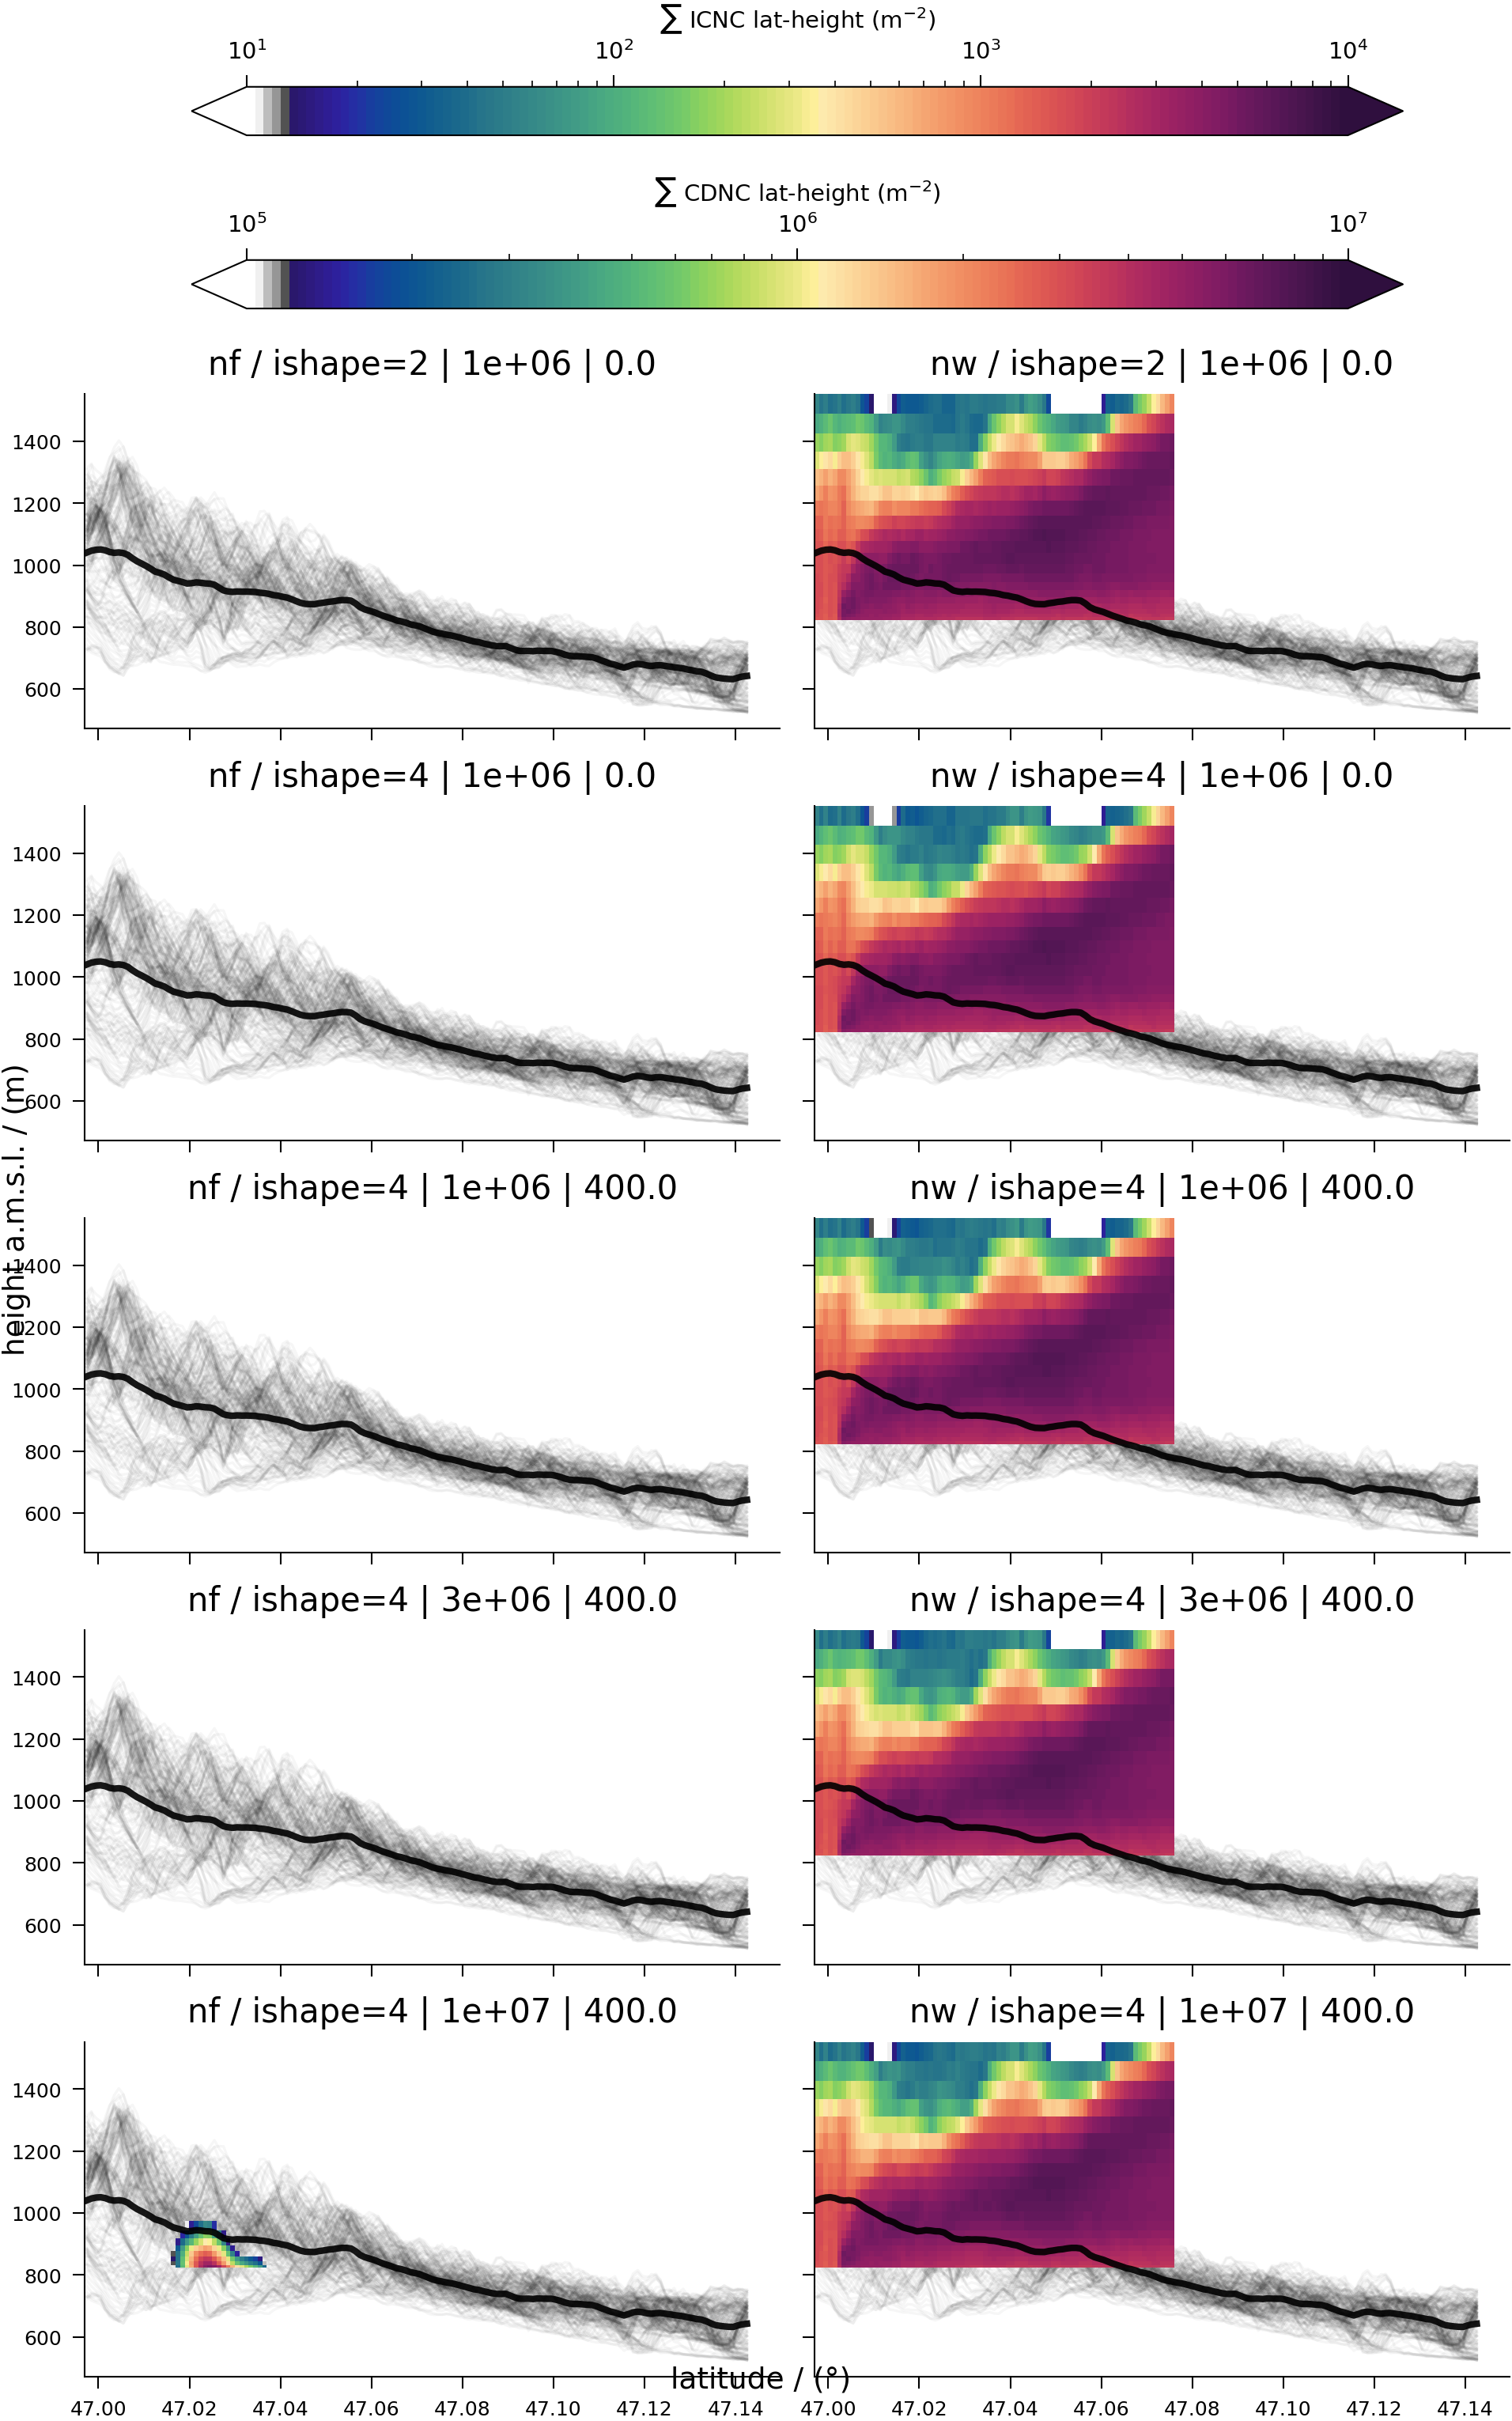

In [ ]:
# plot lat height frames
idx_time = min(130, len(time1d) - 1)
n_flare = len(flare_candidates)
fig_w = (cfg["pixel_size_latheight"][0] / cfg["dpi"])
fig_h = cfg["pixel_size_latheight"][1] / cfg["dpi"] * max(1, n_flare)
fig_lh, axs_lh = plt.subplots(n_flare, 2, figsize=(fig_w, fig_h), sharex=True, sharey=True, constrained_layout=True)
if n_flare == 1:
    axs_lh = np.array([axs_lh])

pm_nf_lh_all, pm_nw_lh_all = [], []
for ax, exp in zip(axs_lh, flare_candidates):
    ax[0].plot(lat1d, surf_height_mean, color="black", alpha=0.9, lw=2, zorder=3)
    ax[1].plot(lat1d, surf_height_mean, color="black", alpha=0.9, lw=2, zorder=3)
    if cfg.get("latheight_surf_mode", "all_mean") == "all_mean":
        ax[0].plot(lat1d, surf_height, color="black", alpha=0.035 if "100m" in cfg["resolution"] else 0.075)
        ax[1].plot(lat1d, surf_height, color="black", alpha=0.035 if "100m" in cfg["resolution"] else 0.075)
    pm_nf = ax[0].pcolormesh(
        lat1d[: lat_by_exp[exp].shape[-1]],
        height1d,
        lat_by_exp[exp].isel(time=idx_time).values,
        cmap=new_fjet2,
        norm=LogNorm(*cfg["v_lims_qi"]),
        shading="nearest",
        zorder=2,
    )
    pm_nf_lh_all.append(pm_nf)
    pm_nw = ax[1].pcolormesh(
        lat1d[: lat_by_exp[exp].shape[-1]],
        height1d,
        lat_by_exp2[exp].isel(time=idx_time).values,
        cmap=new_fjet2,
        norm=LogNorm(vmin=1e5, vmax=1e7),
        shading="nearest",
        zorder=2,
    )
    pm_nw_lh_all.append(pm_nw)
    for iax, name in zip(ax, ["nf", "nw"]):
        iax.set_title(f"{name} / ishape={_ishape_of(exp)} | {_flare_emission_inp_of(exp):.0e} | {_flare_emission_ccn_of(exp)}", fontsize=10)
        iax.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)
        iax.spines["top"].set_visible(False)
        iax.spines["right"].set_visible(False)

fig_lh.text(0.5, 0.02, "latitude / (°)", ha="center", va="center", fontsize=cfg["axis_size"])
fig_lh.text(0.01, 0.5, "height a.m.s.l. / (m)", ha="center", va="center", fontsize=cfg["axis_size"], rotation="vertical")
cb_nf_lh = fig_lh.colorbar(pm_nf_lh_all[0], ax=axs_lh.ravel().tolist(), pad=0.02, extend="both", shrink=0.85, aspect=25, orientation="horizontal", location="top")
cb_nf_lh.set_label(r"$\sum$ ICNC lat-height (m$^{-2}$)")
cb_nf_lh.ax.tick_params(labelsize=cfg["tick_size"])

cb_nw_lh = fig_lh.colorbar(pm_nw_lh_all[0], ax=axs_lh.ravel().tolist(), pad=0.02, extend="both", shrink=0.85, aspect=25, orientation="horizontal", location="top")
cb_nw_lh.set_label(r"$\sum$ CDNC lat-height (m$^{-2}$)")
cb_nw_lh.ax.tick_params(labelsize=cfg["tick_size"])

In [ ]:
for f in glob.glob(str(GFX_PNG / "lat_height_frame_*.png")):
    os.remove(f)

if cfg["plot_all_frames"]:
    for iframe in range(len(time1d)):
        for txt in fig_lh.texts:
            if "UTC" in txt.get_text():
                txt.set_visible(False)
        for pm_nf, pm_nw, exp in zip(pm_nf_lh_all, pm_nw_lh_all, flare_candidates):
            pm_nf.set_array(np.asarray(lat_by_exp[exp].isel(time=iframe).values).ravel())
            pm_nw.set_array(np.asarray(lat_by_exp2[exp].isel(time=iframe).values).ravel())
        cur = time1d[iframe]
        ts = np.datetime_as_string(cur, unit="s").replace("T", "  ")
        fig_lh.text(0.98, 0.98, f"{ts[-8:]} UTC", ha="right", va="top", fontweight="semibold", fontsize=cfg["timer_size"])
        
        out = GFX_PNG / f"lat_height_frame_{iframe:03d}_{cfg['resolution']}.png"
        fig_lh.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")

    pat = str(GFX_PNG / f"lat_height_frame_%03d_{cfg['resolution']}.png")
    mp4_lh = GFX_MP4 / f"lat_height_multi_flare_{cfg['resolution']}_{cs_run.replace('__', '_')}.mp4"
    # gif_lh = mp4_lh.with_suffix(".gif")
    tools.convert_to_video(pat, str(mp4_lh), resolution="1920:1080", loop_count=2, framerate=20)
    # tools.convert_to_gif(pat, str(gif_lh), scale_factor=0.5, fps=10)
    # print(mp4_lh, gif_lh)
else:
    for pm_nf, pm_nw, exp in zip(pm_nf_lh_all, pm_nw_lh_all, flare_candidates):
        pm_nf.set_array(np.asarray(lat_by_exp[exp].isel(time=0).values).ravel())
        pm_nw.set_array(np.asarray(lat_by_exp2[exp].isel(time=0).values).ravel())


FFMPEG created MP4 file: /home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/mp4/lat_height_multi_flare_100m_cs-eriswil_20260318_153631.mp4


# FINAL CONCANTENATION OF MP4S


**Combine top + side MP4 (server ffmpeg):**

In [ ]:
import os
import subprocess
from pathlib import Path

polarcap_root = Path(os.environ["POLARCAP_ROOT"]) 
input_lat_lon = polarcap_root / "output/gfx/mp4/lat_lon_multi_flare_100m_cs-eriswil_20260318_153631.mp4"
input_lat_height = polarcap_root / "output/gfx/mp4/lat_height_multi_flare_100m_cs-eriswil_20260318_153631.mp4"

ffmpeg_bin = "/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-wuuo72/bin/ffmpeg"
out_mp4 = polarcap_root / "output/gfx/mp4/all_combined_multi_flare_100m_cs-eriswil_20260318_153631_1920x1080.mp4"
out_mp4.parent.mkdir(parents=True, exist_ok=True)

cmd = [
    ffmpeg_bin,
    "-y",
    "-i", input_lat_lon,
    "-i", input_lat_height,
    "-filter_complex",
    "[0:v]fps=15,scale=960:1080:force_original_aspect_ratio=decrease,pad=960:1080:(ow-iw)/2:(oh-ih)/2[top];"
    "[1:v]fps=15,scale=960:1080:force_original_aspect_ratio=decrease,pad=960:1080:(ow-iw)/2:(oh-ih)/2[side];"
    "[top][side]hstack=inputs=2[v]",
    "-map", "[v]",
    "-r", "15",
    "-c:v", "libx264",
    "-crf", "18",
    "-preset", "slow",
    "-pix_fmt", "yuv420p",
    "-movflags", "+faststart",
    "-shortest",
    str(out_mp4),
]

subprocess.run(cmd, check=True)
out_mp4.resolve().as_uri()


ffmpeg version 5.1.2 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 10.4.0 (conda-forge gcc 10.4.0-18)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1666357487580/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1666357487580/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1666357487580/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1666357487580/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1666357487580/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --disable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libfontconfig --enable-libopenh264 --enable-gnu

'file:///home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/mp4/all_combined_multi_flare_100m_cs-eriswil_20260318_153631_1920x1080.mp4'